In [52]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import seaborn as sns
import math
import copy
from sklearn.utils import resample

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [53]:
train_df = pd.read_csv('data/processed/train_FD001_processed.csv')
test_df = pd.read_csv('data/processed/test_FD001_processed.csv')

print(train_df.head())

   engine  cycle  setting1  setting2  setting3  Fan Inlet Temperature (°K)  \
0       1      1   -0.0007   -0.0004     100.0                      288.15   
1       1      2    0.0019   -0.0003     100.0                      288.15   
2       1      3   -0.0043    0.0003     100.0                      288.15   
3       1      4    0.0007    0.0000     100.0                      288.15   
4       1      5   -0.0019   -0.0002     100.0                      288.15   

   LPC Outlet Temperature (°K)  HPC Outlet Temperature (°K)  \
0                   356.566667                   883.166667   
1                   356.750000                   884.344444   
2                   356.861111                   882.216667   
3                   356.861111                   879.327778   
4                   356.872222                   879.361111   

   LPT Outlet Temperature (°K)  Fan Inlet Pressure (kPa)  ...  \
0                   778.111111                100.801391  ...   
1                   77

In [54]:
index_cols = ["engine", "cycle"]
setting_cols = ["setting1", "setting2", "setting3"]

sensor_cols = [
    "Fan Inlet Temperature (°K)",
    "LPC Outlet Temperature (°K)",
    "HPC Outlet Temperature (°K)",
    "LPT Outlet Temperature (°K)",
    "Fan Inlet Pressure (kPa)",
    "Bypass-Duct Pressure (kPa)",
    "HPC Outlet Pressure (kPa)",
    "Physical Fan Speed (rpm)",
    "Physical Core Speed (rpm)",
    "Engine Pressure Ratio (P50/P2)",
    "HPC Outlet Static Pressure (kPa)",
    "Ratio of Fuel Flow to Ps30 (m²/s)",
    "Corrected Fan Speed (rpm)",
    "Corrected Core Speed (rpm)",
    "Bypass Ratio",
    "Burner Fuel-Air Ratio",
    "Bleed Enthalpy",
    "Required Fan Speed",
    "Required Fan Conversion Speed",
    "High-Pressure Turbines Cool Air Flow",
    "Low-Pressure Turbines Cool Air Flow"
]

In [55]:
window_size = 5

for sensor in sensor_cols:
    train_df[f'{sensor}_rolling_mean'] = (
        train_df.groupby('engine')[sensor].transform(lambda x: x.rolling(window_size, min_periods=1).mean())
    )
    train_df[f'{sensor}_rolling_std'] = (
        train_df.groupby('engine')[sensor].transform(lambda x: x.rolling(window_size, min_periods=1).std())
    )

    test_df[f'{sensor}_rolling_mean'] = (
        test_df.groupby('engine')[sensor].transform(lambda x: x.rolling(window_size, min_periods=1).mean())
    )
    test_df[f'{sensor}_rolling_std'] = (
        test_df.groupby('engine')[sensor].transform(lambda x: x.rolling(window_size, min_periods=1).std())
    )

train_df.fillna(0, inplace=True)
test_df.fillna(0, inplace=True)


In [56]:
# Use ONLY raw sensor columns for baseline
feature_cols_initial = sensor_cols

train_baseline = (
    train_df.groupby('engine')[feature_cols_initial]
    .head(5)
    .groupby(train_df['engine'])
    .mean()
)
train_baseline.columns = [c + "_baseline" for c in train_baseline.columns]

train_df = train_df.join(train_baseline, on='engine', how='left')

test_baseline = (
    test_df.groupby('engine')[feature_cols_initial]
    .head(5)
    .groupby(test_df['engine'])
    .mean()
)
test_baseline.columns = [c + "_baseline" for c in test_baseline.columns]

test_df = test_df.join(test_baseline, on='engine', how='left')

# Now create delta features correctly
for c in feature_cols_initial:
    train_df[c + "_delta"] = train_df[c] - train_df[c + "_baseline"]
    test_df[c + "_delta"]  = test_df[c] - test_df[c + "_baseline"]


In [57]:
np.random.seed(42)
all_engines = train_df['engine'].unique()
np.random.shuffle(all_engines)
split = int(len(all_engines) * 0.8)

train_engines = all_engines[:split]
val_engines   = all_engines[split:]

train_subset_df = train_df[train_df['engine'].isin(train_engines)]
val_subset_df   = train_df[train_df['engine'].isin(val_engines)]

feature_cols = [c for c in train_df.columns if c not in ['engine','cycle','RUL']]

scaler = StandardScaler()
scaler.fit(train_subset_df[feature_cols])

train_subset_df[feature_cols] = scaler.transform(train_subset_df[feature_cols])
val_subset_df[feature_cols]   = scaler.transform(val_subset_df[feature_cols])
test_df[feature_cols]         = scaler.transform(test_df[feature_cols])

/tmp/ipykernel_145318/3850810423.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_subset_df[feature_cols] = scaler.transform(train_subset_df[feature_cols])
/tmp/ipykernel_145318/3850810423.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_subset_df[feature_cols]   = scaler.transform(val_subset_df[feature_cols])


In [58]:
LOOKBACK = 50

def create_windows(df, lookback, features):
    X, y = [], []
    for eng in df['engine'].unique():
        d = df[df.engine == eng]
        for i in range(len(d)-lookback+1):
            X.append(d.iloc[i:i+lookback][features].values)
            y.append(d.iloc[i+lookback-1].RUL)
    return np.array(X), np.array(y).reshape(-1,1)

def get_test_windows(df, lookback, features):
    X, y = [], []
    for eng in df.engine.unique():
        d = df[df.engine == eng]
        if len(d) >= lookback:
            X.append(d.iloc[-lookback:][features].values)
            y.append(d.iloc[-1].RUL)
    return np.array(X), np.array(y).reshape(-1,1)

X_train_np, y_train_np = create_windows(train_subset_df, LOOKBACK, feature_cols)
X_val_np,   y_val_np   = create_windows(val_subset_df, LOOKBACK, feature_cols)
X_test_np,  y_test_np  = get_test_windows(test_df, LOOKBACK, feature_cols)

In [59]:
def rebalance_by_rul_bins(X, y, bin_width=20, target_per_bin=2000):
    Xb, yb = [], []
    bins = np.arange(0, 400, bin_width)
    ids = np.digitize(y.flatten(), bins)
    for b in range(1, len(bins)):
        idx = np.where(ids == b)[0]
        if len(idx) == 0:
            continue
        if len(idx) > target_per_bin:
            idx = resample(idx, replace=False, n_samples=target_per_bin, random_state=42)
        else:
            idx = resample(idx, replace=True, n_samples=target_per_bin, random_state=42)
        Xb.append(X[idx])
        yb.append(y[idx])
    return np.concatenate(Xb), np.concatenate(yb)

X_train_np_bal, y_train_np_bal = rebalance_by_rul_bins(X_train_np, y_train_np)

In [60]:
X_train = torch.from_numpy(X_train_np_bal).float()
y_train = torch.from_numpy(y_train_np_bal).float()
X_val   = torch.from_numpy(X_val_np).float()
y_val   = torch.from_numpy(y_val_np).float()
X_test  = torch.from_numpy(X_test_np).float()
y_test  = torch.from_numpy(y_test_np).float()

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)

In [61]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class CNNTransformerRUL(nn.Module):
    def __init__(self, input_dim, d_model, nhead, d_hid, nlayers, dropout):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_dim, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.pos = PositionalEncoding(d_model, dropout)
        enc_layer = nn.TransformerEncoderLayer(d_model, nhead, d_hid, dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, nlayers)
        self.post_norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(nn.Linear(d_model, d_model//2), nn.ReLU(), nn.Linear(d_model//2, 1))

    def forward(self, x):
        x = x.permute(0,2,1)
        x = self.cnn(x)
        x = x.permute(0,2,1)
        x = self.pos(x)
        x = self.transformer(x)
        x = self.post_norm(x)
        x = torch.mean(x, dim=1)
        return self.head(x)

model = CNNTransformerRUL(X_train.shape[2], 128, 8, 256, 4, 0.2).to(device)

In [62]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.2, patience=5)

best_val = float('inf')
patience = 15
no_improve = 0
history = {'train':[], 'val':[]}

for epoch in range(1,150):
    model.train()
    total = 0
    for Xb,yb in train_loader:
        Xb,yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()
        total += loss.item()
    train_loss = total/len(train_loader)

    model.eval()
    total=0
    with torch.no_grad():
        for Xb,yb in val_loader:
            Xb,yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            total += criterion(pred,yb).item()
    val_loss = total/len(val_loader)

    history['train'].append(train_loss)
    history['val'].append(val_loss)

    print(f"Epoch {epoch:03d} | Train {train_loss:.2f} | Val {val_loss:.2f}")

    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        best = copy.deepcopy(model.state_dict())
        no_improve = 0
        print("✅ Saving Best Model")
    else:
        no_improve += 1

    if no_improve >= patience:
        print("❌ Early Stopping")
        break

model.load_state_dict(best)

Epoch 001 | Train 31735.14 | Val 9723.65
✅ Saving Best Model
Epoch 002 | Train 28466.40 | Val 7743.16
✅ Saving Best Model
Epoch 003 | Train 23976.93 | Val 5408.75
✅ Saving Best Model
Epoch 004 | Train 18501.84 | Val 3180.76
✅ Saving Best Model
Epoch 005 | Train 12710.03 | Val 1570.68
✅ Saving Best Model
Epoch 006 | Train 7350.47 | Val 815.80
✅ Saving Best Model
Epoch 007 | Train 3248.68 | Val 530.53
✅ Saving Best Model
Epoch 008 | Train 982.81 | Val 581.00
Epoch 009 | Train 219.13 | Val 727.36
Epoch 010 | Train 74.39 | Val 672.59
Epoch 011 | Train 45.52 | Val 718.80
Epoch 012 | Train 36.44 | Val 765.51
Epoch 013 | Train 30.72 | Val 748.22
Epoch 014 | Train 23.80 | Val 745.61
Epoch 015 | Train 22.91 | Val 775.24
Epoch 016 | Train 21.75 | Val 768.73
Epoch 017 | Train 21.21 | Val 774.57
Epoch 018 | Train 20.66 | Val 804.40
Epoch 019 | Train 19.87 | Val 787.69
Epoch 020 | Train 18.60 | Val 779.18
Epoch 021 | Train 18.61 | Val 787.11
Epoch 022 | Train 18.76 | Val 790.69
❌ Early Stopping


<All keys matched successfully>

In [63]:
model.eval()
preds=[]
with torch.no_grad():
    for X,_ in val_loader:
        preds.append(model(X.to(device)).cpu().numpy())
y_val_pred = np.concatenate(preds).flatten()
y_val_true = y_val_np.flatten()

mask = y_val_true >= 150
slope,_ = np.polyfit(y_val_true[mask], y_val_pred[mask],1)
print("Slope ≥150:", round(slope,3))

Slope ≥150: 0.628


In [64]:
model.eval()
y_pred_list = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        output = model(batch_X)
        y_pred_list.append(output.cpu().numpy())

y_pred_test = np.concatenate(y_pred_list, axis=0).flatten()
y_test_np_flat = y_test_np.flatten()

# Calculate final metrics on the test set
mae_test = mean_absolute_error(y_test_np_flat, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_np_flat, y_pred_test))

print("\n--- Test Set Performance ---")
print(f"Test MAE: {mae_test:.2f}")
print(f"Test RMSE: {rmse_test:.2f}\n")


--- Test Set Performance ---
Test MAE: 18.77
Test RMSE: 28.37



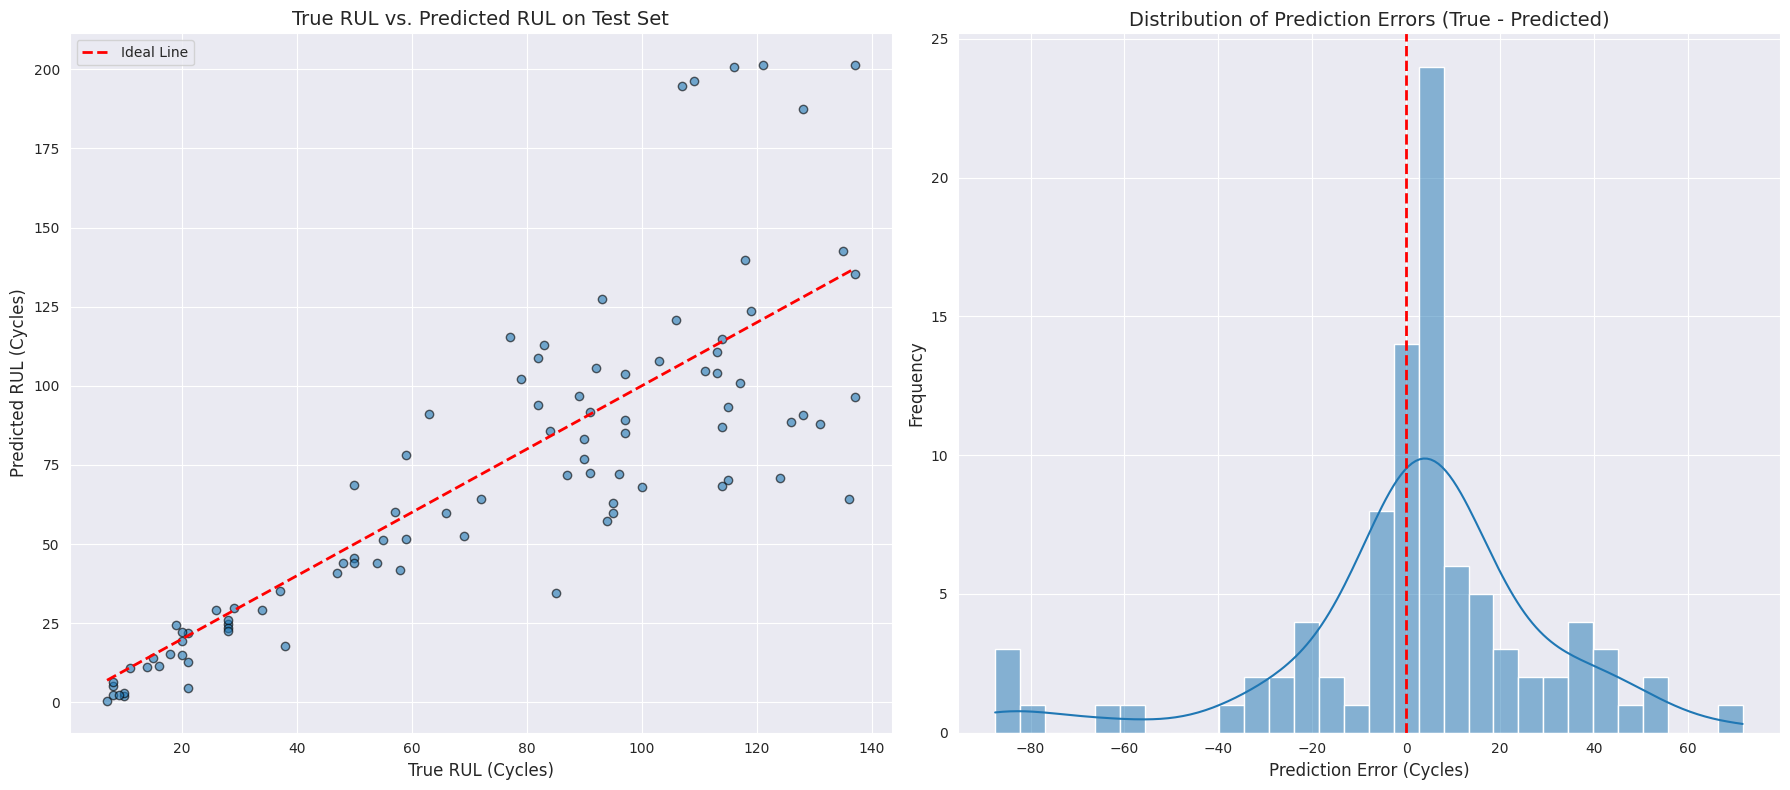

In [65]:
plt.figure(figsize=(18, 8))

# 1. True RUL vs. Predicted RUL
plt.subplot(1, 2, 1)
plt.scatter(y_test_np_flat, y_pred_test, alpha=0.6, edgecolors='k')
plt.plot([min(y_test_np_flat), max(y_test_np_flat)], [min(y_test_np_flat), max(y_test_np_flat)], color='red', linestyle='--', lw=2, label='Ideal Line')
plt.title('True RUL vs. Predicted RUL on Test Set', fontsize=14)
plt.xlabel('True RUL (Cycles)', fontsize=12)
plt.ylabel('Predicted RUL (Cycles)', fontsize=12)
plt.grid(True)
plt.legend()

# 2. Distribution of Prediction Errors
errors = y_test_np_flat - y_pred_test
plt.subplot(1, 2, 2)
sns.histplot(errors, bins=30, kde=True)
plt.title('Distribution of Prediction Errors (True - Predicted)', fontsize=14)
plt.xlabel('Prediction Error (Cycles)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.grid(True)

plt.tight_layout()
plt.show()

In [66]:
model.eval()
y_val_pred_list = []
with torch.no_grad():
    for batch_X, _ in val_loader:
        batch_X = batch_X.to(device)
        output = model(batch_X)
        y_val_pred_list.append(output.cpu().numpy())
y_val_pred = np.concatenate(y_val_pred_list, axis=0).flatten()
y_val_np_flat = y_val_np.flatten()
mae_val = mean_absolute_error(y_val_np_flat, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val_np_flat, y_val_pred))
print("\n--- Validation Set Performance ---")
print(f"Validation MAE: {mae_val:.2f}")
print(f"Validation RMSE: {rmse_val:.2f}\n")


--- Validation Set Performance ---
Validation MAE: 16.68
Validation RMSE: 23.09



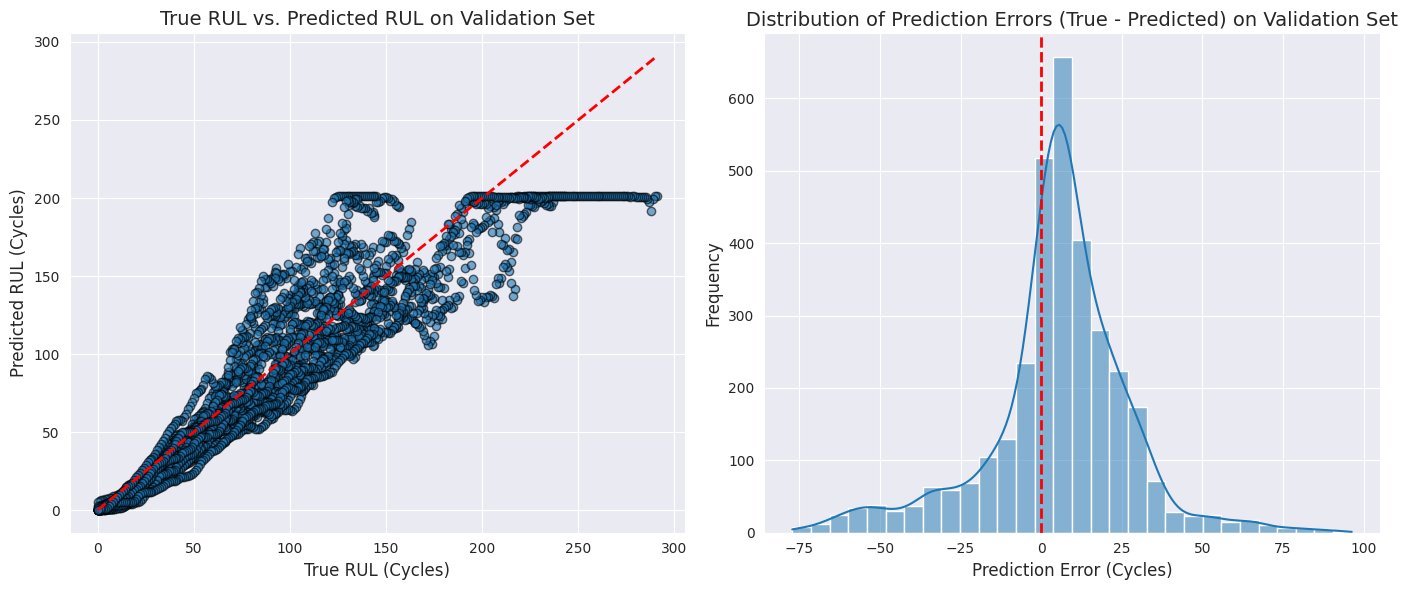

In [67]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_val_np_flat, y_val_pred, alpha=0.6, edgecolors='k')
plt.plot([min(y_val_np_flat), max(y_val_np_flat)], [min(y_val_np_flat), max(y_val_np_flat)], color='red',
         linestyle='--', lw=2)
plt.title('True RUL vs. Predicted RUL on Validation Set', fontsize=14)
plt.xlabel('True RUL (Cycles)', fontsize=12)
plt.ylabel('Predicted RUL (Cycles)', fontsize=12)
plt.grid(True)
errors_val = y_val_np_flat - y_val_pred
plt.subplot(1, 2, 2)
sns.histplot(errors_val, bins=30, kde=True)
plt.title('Distribution of Prediction Errors (True - Predicted) on Validation Set', fontsize=14)
plt.xlabel('Prediction Error (Cycles)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.grid(True)
plt.tight_layout()
plt.show()

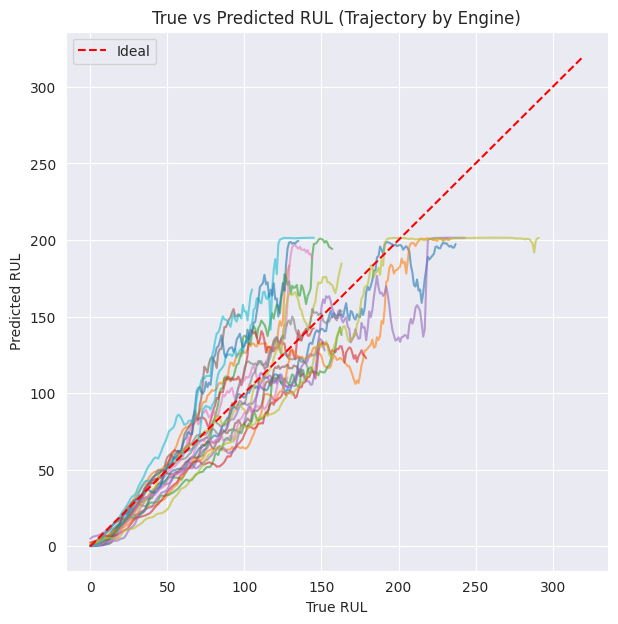

In [68]:
val_df = val_subset_df.copy()
val_df["pred"] = np.nan

index = 0
for eng in val_df.engine.unique():
    d = val_df[val_df.engine == eng]
    seq_len = len(d)
    if seq_len >= LOOKBACK:
        val_df.loc[d.index[LOOKBACK-1:], "pred"] = y_val_pred[index:index+(seq_len-LOOKBACK+1)]
        index += (seq_len - LOOKBACK + 1)

plt.figure(figsize=(7,7))
for eng in val_df.engine.unique():
    d = val_df[val_df.engine == eng]
    plt.plot(d["RUL"].values, d["pred"].values, alpha=0.6)

plt.plot([0, 320], [0, 320], 'r--', label="Ideal")
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("True vs Predicted RUL (Trajectory by Engine)")
plt.legend()
plt.grid(True)
plt.show()

## Diagnosis

LOOKBACK: 50
Max RUL in *raw* train windows: 312.0
Max RUL in *rebalanced* train windows: 312.0


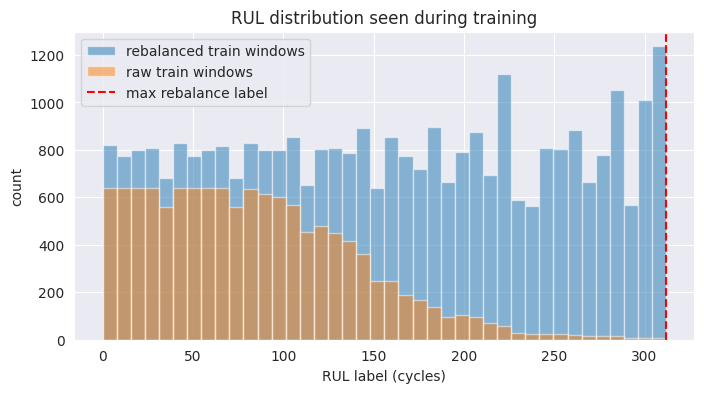

In [70]:
print("LOOKBACK:", LOOKBACK)
print("Max RUL in *raw* train windows:", float(y_train_np.max()))
print("Max RUL in *rebalanced* train windows:", float(y_train_np_bal.max()))

plt.figure(figsize=(8,4))
plt.hist(y_train_np_bal.flatten(), bins=40, alpha=0.5, label="rebalanced train windows")
plt.hist(y_train_np.flatten(), bins=40, alpha=0.5, label="raw train windows")
plt.axvline(np.max(y_train_np_bal), color='red', linestyle='--', label='max rebalance label')
plt.xlabel("RUL label (cycles)")
plt.ylabel("count")
plt.legend()
plt.title("RUL distribution seen during training")
plt.grid(True)
plt.show()


In [71]:
y_val_true = y_val_np.flatten()
y_val_pred = y_val_pred  # from your eval code

mask_hi = y_val_true >= 150
if np.sum(mask_hi) > 5:
    slope_hi, intercept_hi = np.polyfit(y_val_true[mask_hi], y_val_pred[mask_hi], 1)
    print("High-RUL slope (true>=150):", slope_hi)
    print("High-RUL intercept:", intercept_hi)
    print("Validation max predicted RUL:", np.max(y_val_pred))
else:
    print("Not enough high-RUL points in val to estimate slope.")

High-RUL slope (true>=150): 0.6284088832615058
High-RUL intercept: 45.29671299772733
Validation max predicted RUL: 201.49446


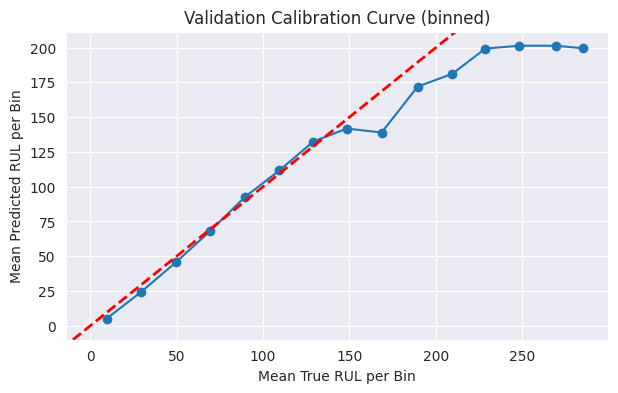

In [72]:
bins = np.arange(0, 330, 20)
bin_ids = np.digitize(y_val_true, bins)

avg_true = []
avg_pred = []
for i in range(1, len(bins)):
    m = bin_ids == i
    if np.any(m):
        avg_true.append(np.mean(y_val_true[m]))
        avg_pred.append(np.mean(y_val_pred[m]))

plt.figure(figsize=(7,4))
plt.plot(avg_true, avg_pred, marker='o')
plt.axline((0,0), slope=1, color='red', linestyle='--', lw=2)
plt.xlabel("Mean True RUL per Bin")
plt.ylabel("Mean Predicted RUL per Bin")
plt.title("Validation Calibration Curve (binned)")
plt.grid(True)
plt.show()

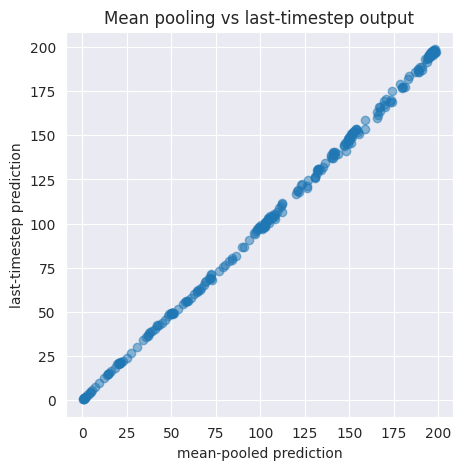

In [73]:
# We'll compare model output vs just "last-timestep-only" features to see if mean-pooling is hurting you.
with torch.no_grad():
    model.eval()

    # Grab a small batch from val
    Xb = X_val[:256].to(device)  # first 256 samples of validation windows
    pred_full = model(Xb).cpu().numpy().flatten()

    # Manually emulate "use only last timestep embedding instead of mean"
    # We'll reuse most of the forward but change pooling:
    def model_last_timestep_only(m, X_input):
        x = X_input.permute(0,2,1)
        x = m.cnn(x)
        x = x.permute(0,2,1)
        x = m.pos(x)
        x = m.transformer(x)
        x = m.post_norm(x)
        x = x[:, -1, :]              # <-- last timestep instead of mean
        return m.head(x)

    pred_tail = model_last_timestep_only(model, Xb).cpu().numpy().flatten()

plt.figure(figsize=(5,5))
plt.scatter(pred_full, pred_tail, alpha=0.5)
plt.xlabel("mean-pooled prediction")
plt.ylabel("last-timestep prediction")
plt.title("Mean pooling vs last-timestep output")
plt.grid(True)
plt.show()

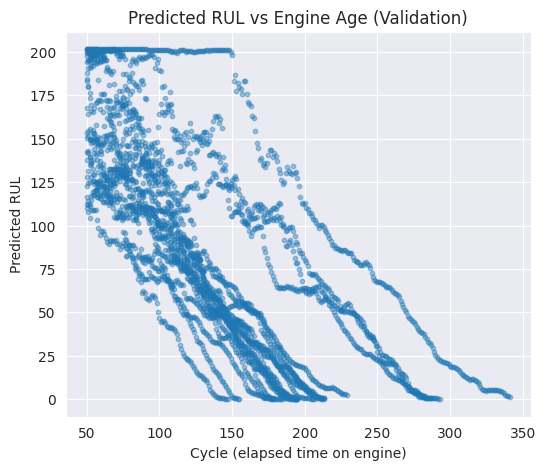

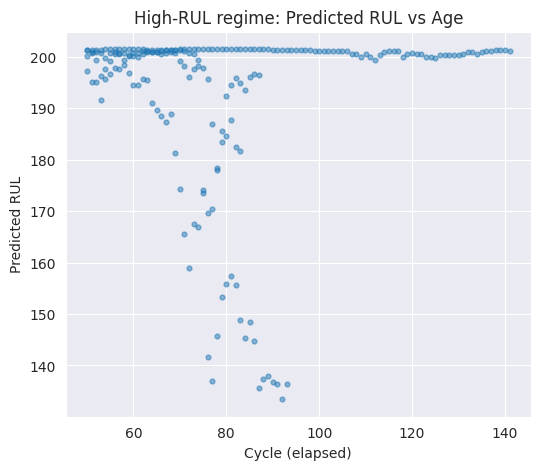

/tmp/ipykernel_145318/1051767981.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_hi["age_bin"] = np.digitize(subset_hi["cycle"], bins)


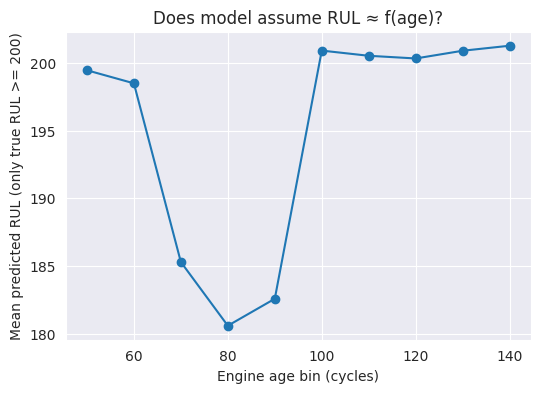

In [74]:
# We reconstruct per-row predictions aligned back to the validation dataframe
val_df = val_subset_df.copy().reset_index(drop=False)
val_df["pred"] = np.nan

idx = 0
for eng in val_df.engine.unique():
    d = val_df[val_df.engine == eng]
    seq_len = len(d)
    if seq_len >= LOOKBACK:
        n_windows = seq_len - LOOKBACK + 1
        val_df.loc[d.index[LOOKBACK-1:], "pred"] = y_val_pred[idx: idx + n_windows]
        idx += n_windows

# Keep only rows where we have a prediction
aligned = val_df.dropna(subset=["pred"]).copy()

# 1. Scatter: engine age (cycle) vs predicted RUL
plt.figure(figsize=(6,5))
plt.scatter(aligned["cycle"], aligned["pred"], alpha=0.4, s=10)
plt.xlabel("Cycle (elapsed time on engine)")
plt.ylabel("Predicted RUL")
plt.title("Predicted RUL vs Engine Age (Validation)")
plt.grid(True)
plt.show()

# 2. For only very healthy states (true RUL >= 200),
#    check spread of predicted RUL at a given age.
mask_hi = aligned["RUL"] >= 200
subset_hi = aligned[mask_hi]

plt.figure(figsize=(6,5))
plt.scatter(subset_hi["cycle"], subset_hi["pred"], alpha=0.5, s=12)
plt.xlabel("Cycle (elapsed)")
plt.ylabel("Predicted RUL")
plt.title("High-RUL regime: Predicted RUL vs Age")
plt.grid(True)
plt.show()

# 3. Bin by age and compute avg predicted RUL in high-RUL regime
bins = np.arange(0, subset_hi["cycle"].max()+10, 10)
subset_hi["age_bin"] = np.digitize(subset_hi["cycle"], bins)

age_bin_centers = []
avg_pred_per_agebin = []
for b in range(1, len(bins)):
    m = subset_hi["age_bin"] == b
    if np.any(m):
        age_bin_centers.append(bins[b-1])
        avg_pred_per_agebin.append(np.mean(subset_hi.loc[m,"pred"]))

plt.figure(figsize=(6,4))
plt.plot(age_bin_centers, avg_pred_per_agebin, marker='o')
plt.xlabel("Engine age bin (cycles)")
plt.ylabel("Mean predicted RUL (only true RUL >= 200)")
plt.title("Does model assume RUL ≈ f(age)?")
plt.grid(True)
plt.show()
